In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

data = pd.read_csv('Animal_Shelter_Intake_and_Outcome.csv')

In [4]:
animal_data = data[['Breed', 'Color', "Sex", "Date Of Birth", "Intake Date", "Outcome Date", "Intake Type", "Type", "Outcome Type", "Intake Condition", "Days in Shelter"]]

print(animal_data.shape)

animal_data = animal_data.rename(
    columns={
    "Breed" : "Breed",
    "Color" : "Color",
    "Sex" : "Sex",
    "Date Of Birth" : "DOB",
    "Intake Date" : 'Intake_Date',
    "Outcome Date" : 'Outcome_Date',
    "Intake Type" : "Intake_Type",
    "Outcome Type" : "Outcome_Type",
    "Intake Condition" : "Intake_Condition",
    "Days in Shelter" : "Days_in_Shelter",
    "Type": "Animal_Type"
})


(26187, 11)


In [5]:
animal_data = animal_data.astype({
    "Breed" : "object",
    "Color" : "category",
    "Sex" : "category",
    "Intake_Type" : "category",
    "Intake_Condition" : "category",
})

animal_data['DOB'] = pd.to_datetime(animal_data["DOB"])
animal_data['Intake_Date'] = pd.to_datetime(animal_data["Intake_Date"])
animal_data['Outcome_Date'] = pd.to_datetime(animal_data["Outcome_Date"])

In [6]:
animal_data['Outcome_Type'] = animal_data['Outcome_Type'].fillna('Not Available')
animal_data['Outcome_Type'] = animal_data['Outcome_Type'].astype('category')

animal_data[['Primary_Color', 'Secondary_Color']] = animal_data['Color'].str.split('/', n=1, expand=True)
animal_data['Primary_Color'].astype('category')

animal_data['Secondary_Color'] = animal_data['Secondary_Color'].fillna("None")
animal_data['Secondary_Color'].astype('category')
animal_data = animal_data.drop(columns=['Color'])

animal_data['Intake_Age'] = (animal_data['Intake_Date'] - animal_data['DOB']).dt.days
animal_data['Intake_Age'] = animal_data['Intake_Age'].fillna(0)
animal_data['Outcome_Age'] = animal_data['Outcome_Date'] - animal_data['DOB']

animal_data['Shelter_Name'] = 'Sonoma County Animal Shelter'

animal_data['Days_in_Shelter'] = animal_data['Days_in_Shelter'].apply(lambda x : str(x) + ' days')
animal_data['Days_in_Shelter'] = pd.to_timedelta(animal_data['Days_in_Shelter'])

In [7]:
missing_values = animal_data.isna().sum()
print(f"Missing values:\n {missing_values}")
animal_data.dropna(inplace=True)
print("Missing Values Dropped ")

duplicated_values = animal_data.duplicated().sum()
print(f"Duplicated Values: {duplicated_values}")
animal_data = animal_data.drop_duplicates()
print("Duplicated Values Dropped")

print(f'Shape: {animal_data.shape}')
animal_data = animal_data.reset_index(drop=True)

Missing values:
 Breed                  0
Sex                    0
DOB                 6467
Intake_Date            0
Outcome_Date         238
Intake_Type            0
Animal_Type            0
Outcome_Type           0
Intake_Condition       0
Days_in_Shelter        0
Primary_Color          0
Secondary_Color        0
Intake_Age             0
Outcome_Age         6660
Shelter_Name           0
dtype: int64
Missing Values Dropped 
Duplicated Values: 627
Duplicated Values Dropped
Shape: (18900, 15)


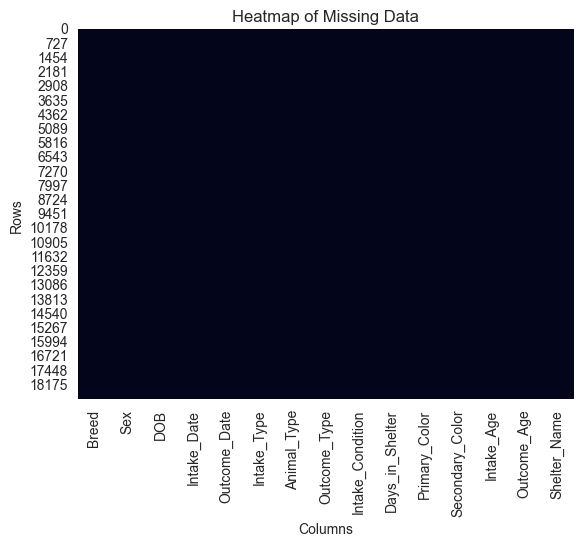

In [8]:
sns.heatmap(animal_data.isnull(), cbar=False)
plt.title("Heatmap of Missing Data")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

In [19]:
animal_data.to_csv('Sonoma_Animal_Data.csv', index=False)
print(animal_data.columns)
print(animal_data['Shelter_Name'].value_counts())

Index(['Breed', 'Sex', 'DOB', 'Intake_Date', 'Outcome_Date', 'Intake_Type',
       'Animal_Type', 'Outcome_Type', 'Intake_Condition', 'Days_in_Shelter',
       'Primary_Color', 'Secondary_Color', 'Intake_Age', 'Outcome_Age',
       'Shelter_Name'],
      dtype='object')
Shelter_Name
Sonoma County Animal Shelter    18900
Name: count, dtype: int64


In [22]:
animal_data.sample(100)
#check DOB and Days_in_Shelter...

,Breed,Sex,DOB,Intake_Date,Outcome_Date,Intake_Type,Animal_Type,Outcome_Type,Intake_Condition,Days_in_Shelter,Primary_Color,Secondary_Color,Intake_Age,Outcome_Age,Shelter_Name
625,CHIHUAHUA SH,Spayed,2004-03-21,2016-03-16,2016-05-06,STRAY,DOG,ADOPTION,HEALTHY,51 days,BROWN,None,4378.0,4429 days,Sonoma County Animal Shelter
18012,SIBERIAN HUSKY,Female,2013-08-31,2019-07-17,2019-07-17,STRAY,DOG,RETURN TO OWNER,UNKNOWN,0 days,UNKNOWN,None,2146.0,2146 days,Sonoma County Animal Shelter
17882,CHIHUAHUA SH,Neutered,2008-06-20,2015-06-09,2015-06-25,STRAY,DOG,ADOPTION,HEALTHY,16 days,TAN,None,2545.0,2561 days,Sonoma County Animal Shelter
14758,DOMESTIC SH,Female,2015-04-06,2015-06-17,2015-07-10,OWNER SURRENDER,CAT,DIED,HEALTHY,23 days,GRAY TABBY,None,72.0,95 days,Sonoma County Animal Shelter
14923,REDBONE HOUND,Male,2011-01-01,2016-12-29,2016-12-29,STRAY,DOG,RETURN TO OWNER,HEALTHY,0 days,RED,None,2189.0,2189 days,Sonoma County Animal Shelter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11577,DOMESTIC SH,Neutered,2009-08-14,2015-08-14,2015-09-09,OWNER SURRENDER,CAT,EUTHANIZE,TREATABLE/REHAB,26 days,BRN TABBY,None,2191.0,2217 days,Sonoma County Animal Shelter
2252,DOMESTIC SH,Neutered,2016-08-07,2016-08-18,2016-10-27,STRAY,CAT,ADOPTION,TREATABLE/REHAB,70 days,WHITE,BLACK,11.0,81 days,Sonoma County Animal Shelter
16599,FOX TERR SMOOTH,Neutered,2007-04-03,2019-04-02,2019-04-03,STRAY,DOG,RETURN TO OWNER,HEALTHY,1 days,TRICOLOR,None,4382.0,4383 days,Sonoma County Animal Shelter
871,PIT BULL,Neutered,2017-02-04,2017-08-04,2017-08-05,STRAY,DOG,RETURN TO OWNER,UNKNOWN,1 days,GRAY,WHITE,181.0,182 days,Sonoma County Animal Shelter


In [11]:
animal_data.describe()

,DOB,Intake_Date,Outcome_Date,Days_in_Shelter,Intake_Age,Outcome_Age
count,18900,18900,18900,18900,18900.000000,18900
mean,2014-08-27 22:33:26.857142784,2018-03-06 13:53:49.714285568,2018-03-28 12:16:59.428571392,21 days 22:23:09.714285714,1286.639153,1308 days 13:43:32.571428560
min,1989-03-04 00:00:00,2013-08-16 00:00:00,2014-01-01 00:00:00,0 days 00:00:00,-1336.000000,-1336 days +00:00:00
25%,2012-02-10 00:00:00,2015-10-15 00:00:00,2015-11-04 00:00:00,2 days 00:00:00,173.000000,186 days 00:00:00
50%,2015-02-22 00:00:00,2017-10-15 00:00:00,2017-11-01 12:00:00,11 days 00:00:00,725.000000,738 days 00:00:00
75%,2018-01-01 00:00:00,2020-02-20 00:00:00,2020-03-11 00:00:00,28 days 00:00:00,1897.250000,1922 days 00:00:00
max,2023-08-30 00:00:00,2023-09-23 00:00:00,2023-09-23 00:00:00,1239 days 00:00:00,10957.000000,11179 days 00:00:00
std,NaN,NaN,NaN,38 days 23:27:38.621683088,1463.541491,1461 days 00:44:07.614472208


In [12]:
animal_data['Days_in_Shelter'].value_counts()

Days_in_Shelter
0 days      2622
1 days      1932
3 days       760
2 days       736
7 days       505
            ... 
747 days       1
280 days       1
237 days       1
318 days       1
256 days       1
Name: count, Length: 283, dtype: int64

In [13]:
animal_data['Intake_Condition'].value_counts()

Intake_Condition
HEALTHY                 10343
UNKNOWN                  4696
TREATABLE/REHAB          1792
TREATABLE/MANAGEABLE     1064
UNTREATABLE              1005
Name: count, dtype: int64

In [14]:
sample = data[data['Intake Condition'] == "UNTREATABLE"]

In [21]:
animal_data['Days_in_Shelter'].value_counts()

Days_in_Shelter
0 days      2622
1 days      1932
3 days       760
2 days       736
7 days       505
            ... 
747 days       1
280 days       1
237 days       1
318 days       1
256 days       1
Name: count, Length: 283, dtype: int64

In [18]:
animal_data.columns

Index(['Breed', 'Sex', 'DOB', 'Intake_Date', 'Outcome_Date', 'Intake_Type',
       'Animal_Type', 'Outcome_Type', 'Intake_Condition', 'Days_in_Shelter',
       'Primary_Color', 'Secondary_Color', 'Intake_Age', 'Outcome_Age',
       'Shelter_Name'],
      dtype='object')

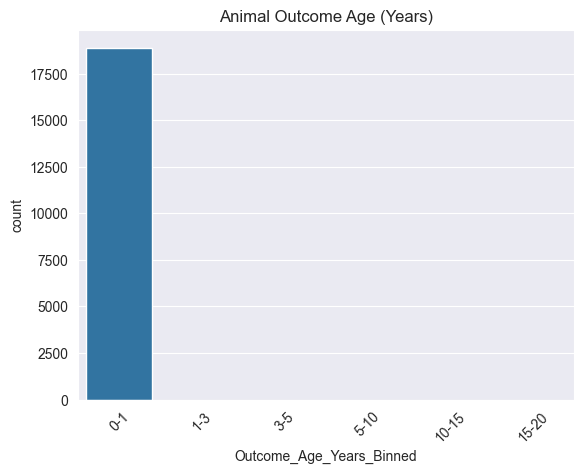

In [24]:
def Simplify_Datetime(text):
    if isinstance(text, str) and ' ' in text:
        num, time = text.split(" ")
        num = int(num)
        if time.lower() == 'days':
            return num
        if time.lower() == 'months':
            return int(round(num * 30.44))
        if time.lower() == 'years':
            return int(round(num * 365.25))
    elif isinstance(text, (int, float)):
        return float(text)
    return 0

animal_data['Outcome_Age_Days'] = animal_data['Outcome_Age'].apply(Simplify_Datetime)
animal_data['Intake_Age_Days'] = animal_data['Intake_Age'].apply(Simplify_Datetime)

animal_data['Outcome_Age_Years'] = animal_data['Outcome_Age_Days'].astype(int).apply(lambda x : round((x / 365.25), 1))
animal_data['Intake_Age_Years'] = animal_data['Intake_Age_Days'].astype(int).apply(lambda x : round((x /  365.25), 1))

bins = [0, 1, 3, 5, 10, 15, 20]
labels = ['0-1', '1-3', '3-5', '5-10', '10-15', '15-20']
animal_data['Outcome_Age_Years_Binned'] = pd.cut(animal_data['Outcome_Age_Years'], bins=bins, labels=labels, right=False)

ax = sns.countplot(data=animal_data, x='Outcome_Age_Years_Binned')
ax.set_title("Animal Outcome Age (Years)")
plt.xticks(rotation=45)
plt.show()